In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_csv('Titanic-Dataset.csv')

In [9]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
# Explore the dataset structure
print("Dataset Shape:", data.shape)
print("\nColumn Names and Types:")
print(data.dtypes)
print("\nMissing Values:")
print(data.isnull().sum())
print("\nBasic Statistics:")
print(data.describe())

Dataset Shape: (891, 12)

Column Names and Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Basic Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000   

In [11]:
# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Survival Analysis

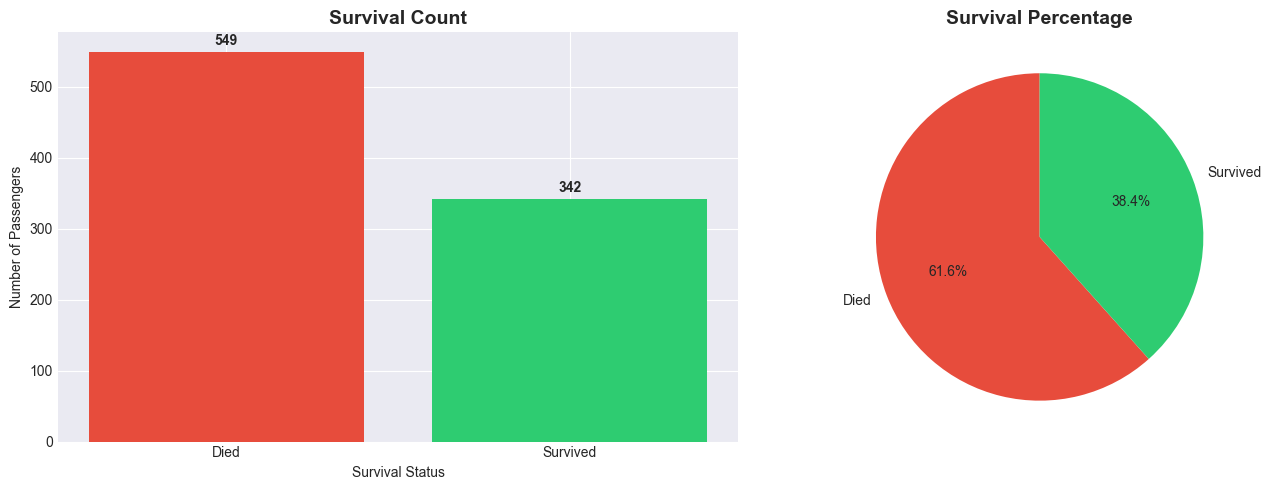

In [12]:
# Bar chart: Overall Survival Count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival Count
survival_counts = data['Survived'].value_counts()
axes[0].bar(['Died', 'Survived'], survival_counts.values, color=['#E74C3C', '#2ECC71'])
axes[0].set_title('Survival Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Passengers')
axes[0].set_xlabel('Survival Status')
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Survival Percentage
survival_pct = data['Survived'].value_counts(normalize=True) * 100
axes[1].pie(survival_pct.values, labels=['Died', 'Survived'], autopct='%1.1f%%', 
            colors=['#E74C3C', '#2ECC71'], startangle=90)
axes[1].set_title('Survival Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Age Distribution Analysis

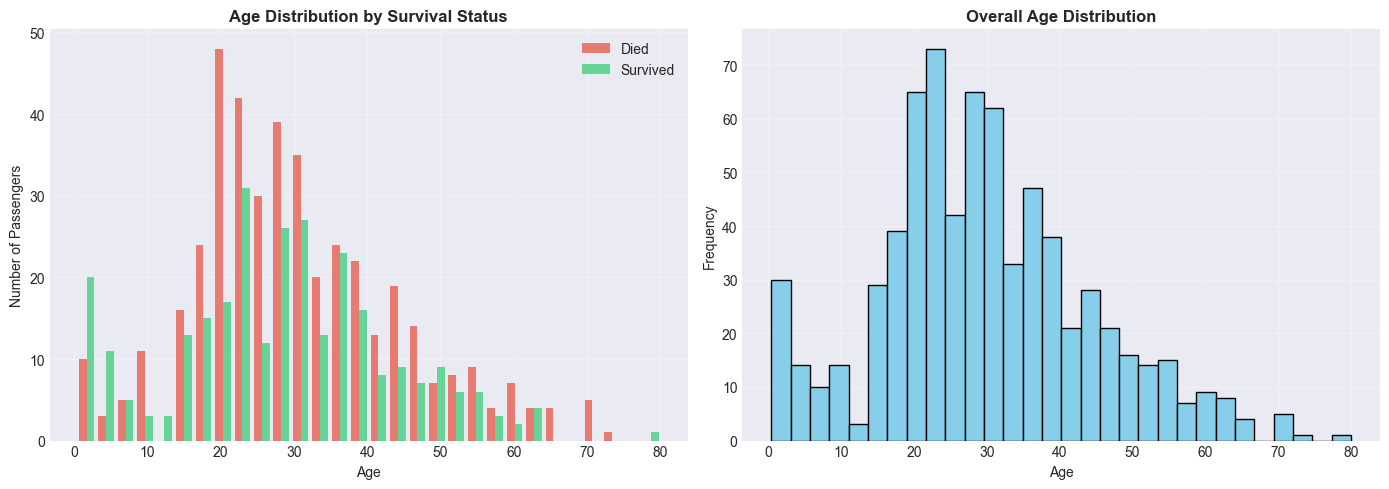

Average Age: 29.70 years
Median Age: 28.00 years
Age Range: 0.42 - 80.00 years


In [13]:
# Histogram: Age Distribution by Survival Status
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist([data[data['Survived']==0]['Age'].dropna(), 
          data[data['Survived']==1]['Age'].dropna()], 
         bins=30, label=['Died', 'Survived'], color=['#E74C3C', '#2ECC71'], alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution by Survival Status', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
data['Age'].dropna().hist(bins=30, edgecolor='black', color='skyblue')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Overall Age Distribution', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Age: {data['Age'].mean():.2f} years")
print(f"Median Age: {data['Age'].median():.2f} years")
print(f"Age Range: {data['Age'].min():.2f} - {data['Age'].max():.2f} years")

## 3. Passenger Class Analysis

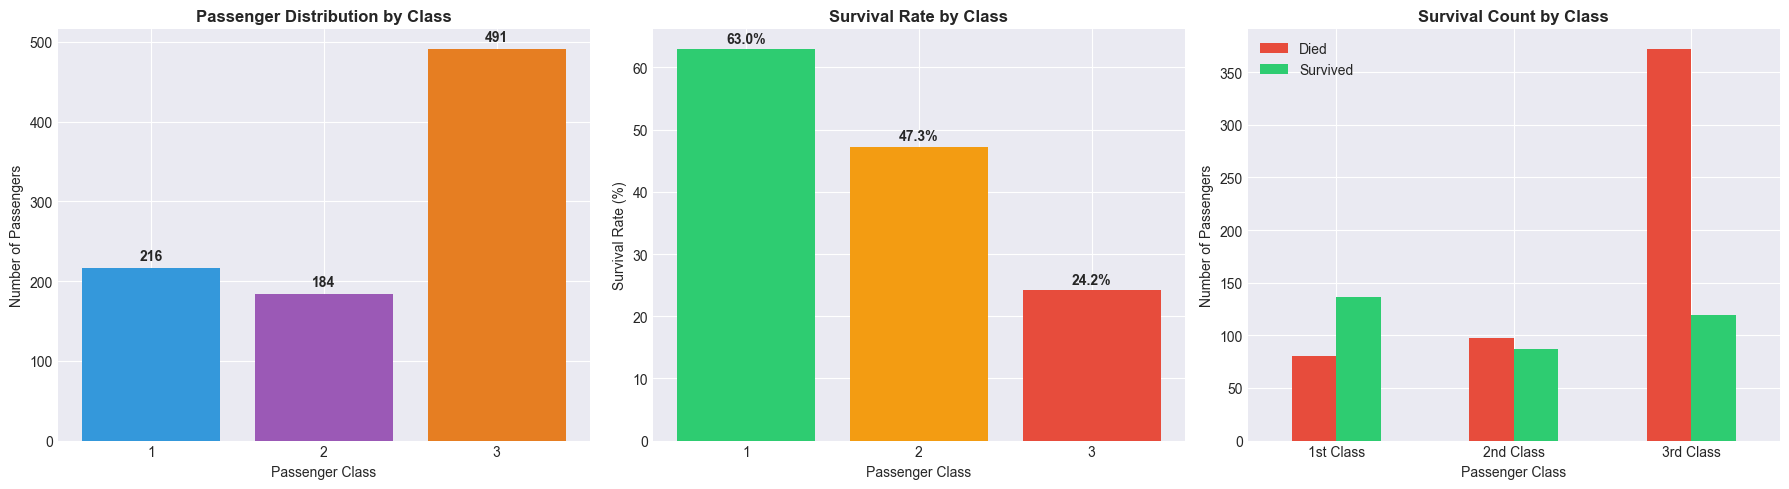

In [14]:
# Bar charts: Passenger Class Distribution and Survival by Class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class Distribution
class_counts = data['Pclass'].value_counts().sort_index()
axes[0].bar(class_counts.index, class_counts.values, color=['#3498DB', '#9B59B6', '#E67E22'])
axes[0].set_title('Passenger Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Number of Passengers')
axes[0].set_xticks([1, 2, 3])
for i, v in enumerate(class_counts.values):
    axes[0].text(i+1, v + 10, str(v), ha='center', fontweight='bold')

# Survival Rate by Class
survival_by_class = data.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(survival_by_class.index, survival_by_class.values, color=['#2ECC71', '#F39C12', '#E74C3C'])
axes[1].set_title('Survival Rate by Class', fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xticks([1, 2, 3])
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i+1, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Stacked bar chart: Survived vs Died by Class
class_survival = pd.crosstab(data['Pclass'], data['Survived'])
class_survival.plot(kind='bar', stacked=False, ax=axes[2], color=['#E74C3C', '#2ECC71'])
axes[2].set_title('Survival Count by Class', fontweight='bold')
axes[2].set_xlabel('Passenger Class')
axes[2].set_ylabel('Number of Passengers')
axes[2].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[2].legend(['Died', 'Survived'])

plt.tight_layout()
plt.show()

## 4. Gender Analysis

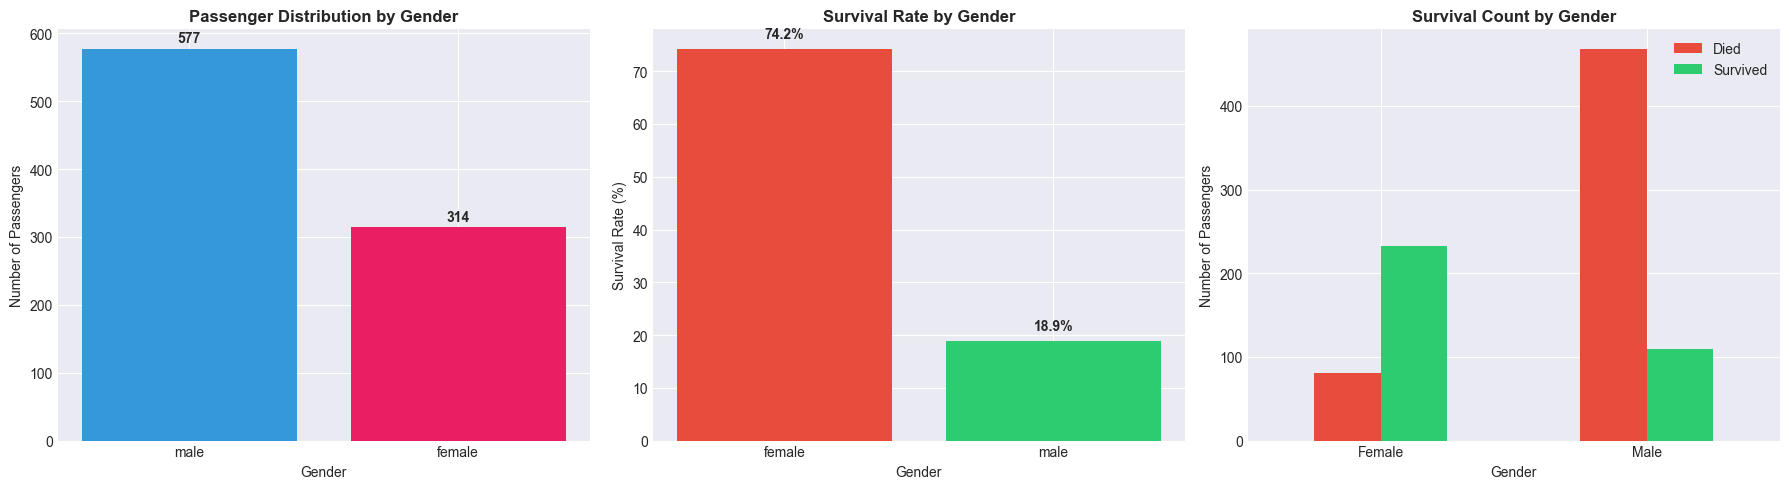

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender Distribution
gender_counts = data['Sex'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#3498DB', '#E91E63'])
axes[0].set_title('Passenger Distribution by Gender', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Passengers')
for i, (idx, v) in enumerate(gender_counts.items()):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Survival Rate by Gender
survival_by_gender = data.groupby('Sex')['Survived'].mean() * 100
axes[1].bar(survival_by_gender.index, survival_by_gender.values, color=['#E74C3C', '#2ECC71'])
axes[1].set_title('Survival Rate by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Survival Rate (%)')
for i, (idx, v) in enumerate(survival_by_gender.items()):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Grouped bar chart: Survived vs Died by Gender
gender_survival = pd.crosstab(data['Sex'], data['Survived'])
gender_survival.plot(kind='bar', ax=axes[2], color=['#E74C3C', '#2ECC71'])
axes[2].set_title('Survival Count by Gender', fontweight='bold')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Number of Passengers')
axes[2].set_xticklabels(['Female', 'Male'], rotation=0)
axes[2].legend(['Died', 'Survived'])

plt.tight_layout()
plt.show()

## 5. Fare Distribution Analysis

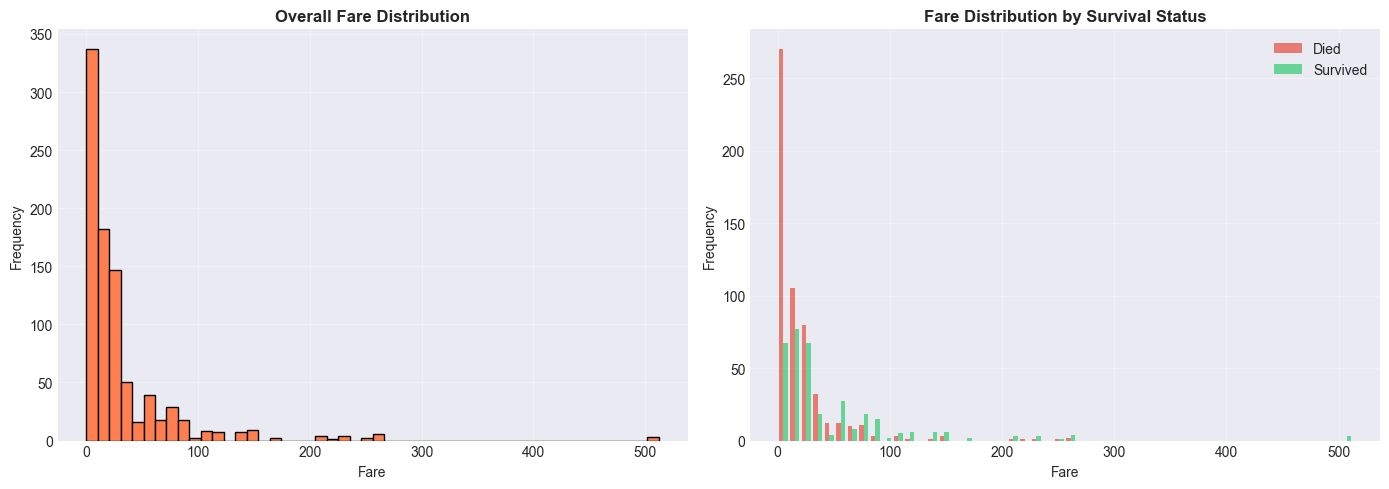

Average Fare: $32.20
Median Fare: $14.45
Fare Range: $0.00 - $512.33


In [16]:
# Histogram: Fare Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall Fare Distribution
axes[0].hist(data['Fare'], bins=50, edgecolor='black', color='coral')
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall Fare Distribution', fontweight='bold')
axes[0].grid(alpha=0.3)

# Fare Distribution by Survival Status
axes[1].hist([data[data['Survived']==0]['Fare'], 
              data[data['Survived']==1]['Fare']], 
             bins=50, label=['Died', 'Survived'], color=['#E74C3C', '#2ECC71'], alpha=0.7)
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Fare Distribution by Survival Status', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Fare: ${data['Fare'].mean():.2f}")
print(f"Median Fare: ${data['Fare'].median():.2f}")
print(f"Fare Range: ${data['Fare'].min():.2f} - ${data['Fare'].max():.2f}")

## 6. Family Size Analysis (SibSp + Parch)

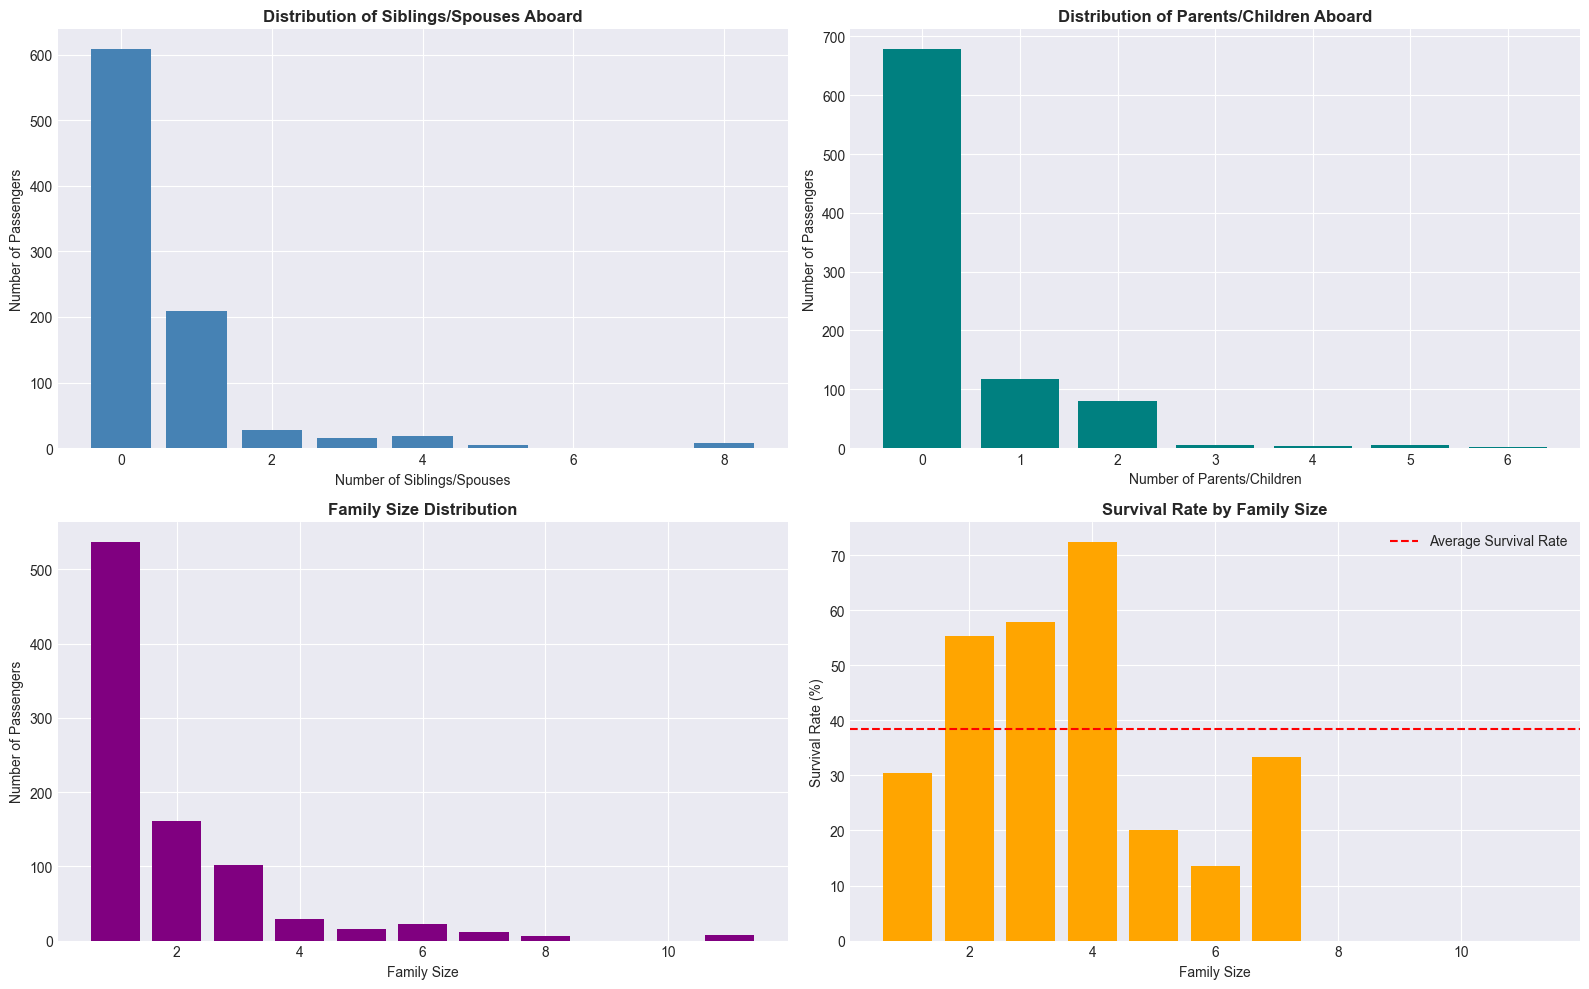

In [17]:
# Create Family Size feature
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

# Bar charts: Family Size Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# SibSp Distribution
sibsp_counts = data['SibSp'].value_counts().sort_index()
axes[0, 0].bar(sibsp_counts.index, sibsp_counts.values, color='steelblue')
axes[0, 0].set_title('Distribution of Siblings/Spouses Aboard', fontweight='bold')
axes[0, 0].set_xlabel('Number of Siblings/Spouses')
axes[0, 0].set_ylabel('Number of Passengers')

# Parch Distribution
parch_counts = data['Parch'].value_counts().sort_index()
axes[0, 1].bar(parch_counts.index, parch_counts.values, color='teal')
axes[0, 1].set_title('Distribution of Parents/Children Aboard', fontweight='bold')
axes[0, 1].set_xlabel('Number of Parents/Children')
axes[0, 1].set_ylabel('Number of Passengers')

# Family Size Distribution
family_counts = data['FamilySize'].value_counts().sort_index()
axes[1, 0].bar(family_counts.index, family_counts.values, color='purple')
axes[1, 0].set_title('Family Size Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Family Size')
axes[1, 0].set_ylabel('Number of Passengers')

# Survival Rate by Family Size
survival_by_family = data.groupby('FamilySize')['Survived'].mean() * 100
axes[1, 1].bar(survival_by_family.index, survival_by_family.values, color='orange')
axes[1, 1].set_title('Survival Rate by Family Size', fontweight='bold')
axes[1, 1].set_xlabel('Family Size')
axes[1, 1].set_ylabel('Survival Rate (%)')
axes[1, 1].axhline(y=data['Survived'].mean()*100, color='red', linestyle='--', label='Average Survival Rate')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 7. Embarkation Port Analysis

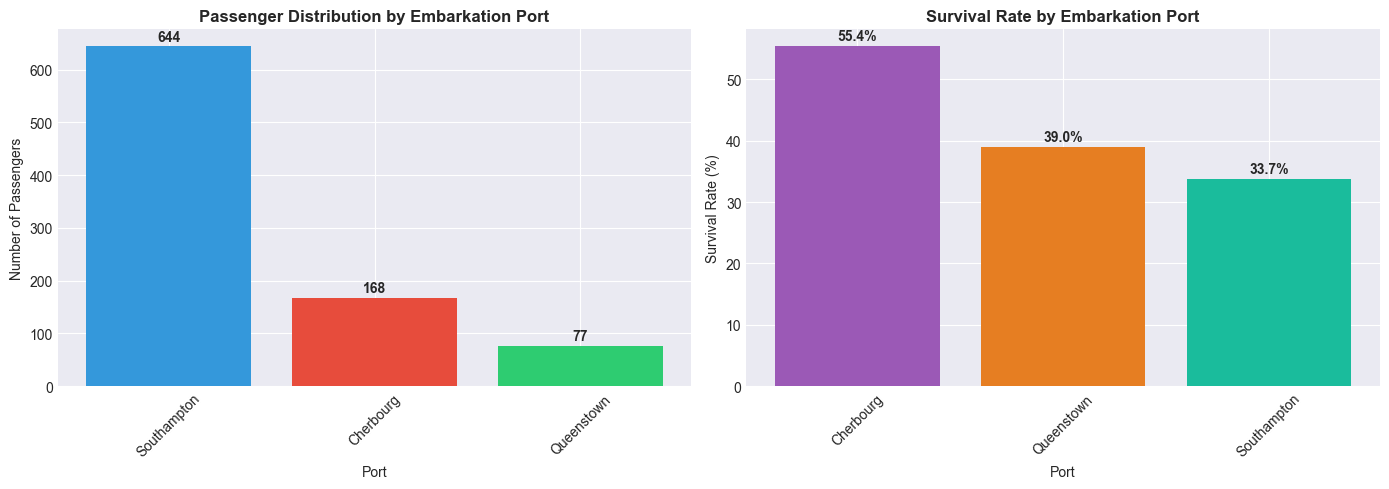

In [18]:
# Bar charts: Embarkation Port Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Port Distribution
port_counts = data['Embarked'].value_counts()
port_labels = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
axes[0].bar(range(len(port_counts)), port_counts.values, 
           tick_label=[port_labels.get(x, x) for x in port_counts.index],
           color=['#3498DB', '#E74C3C', '#2ECC71'])
axes[0].set_title('Passenger Distribution by Embarkation Port', fontweight='bold')
axes[0].set_xlabel('Port')
axes[0].set_ylabel('Number of Passengers')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(port_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Survival Rate by Port
survival_by_port = data.groupby('Embarked')['Survived'].mean() * 100
axes[1].bar(range(len(survival_by_port)), survival_by_port.values,
           tick_label=[port_labels.get(x, x) for x in survival_by_port.index],
           color=['#9B59B6', '#E67E22', '#1ABC9C'])
axes[1].set_title('Survival Rate by Embarkation Port', fontweight='bold')
axes[1].set_xlabel('Port')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(survival_by_port.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Combined Analysis: Class, Gender & Survival

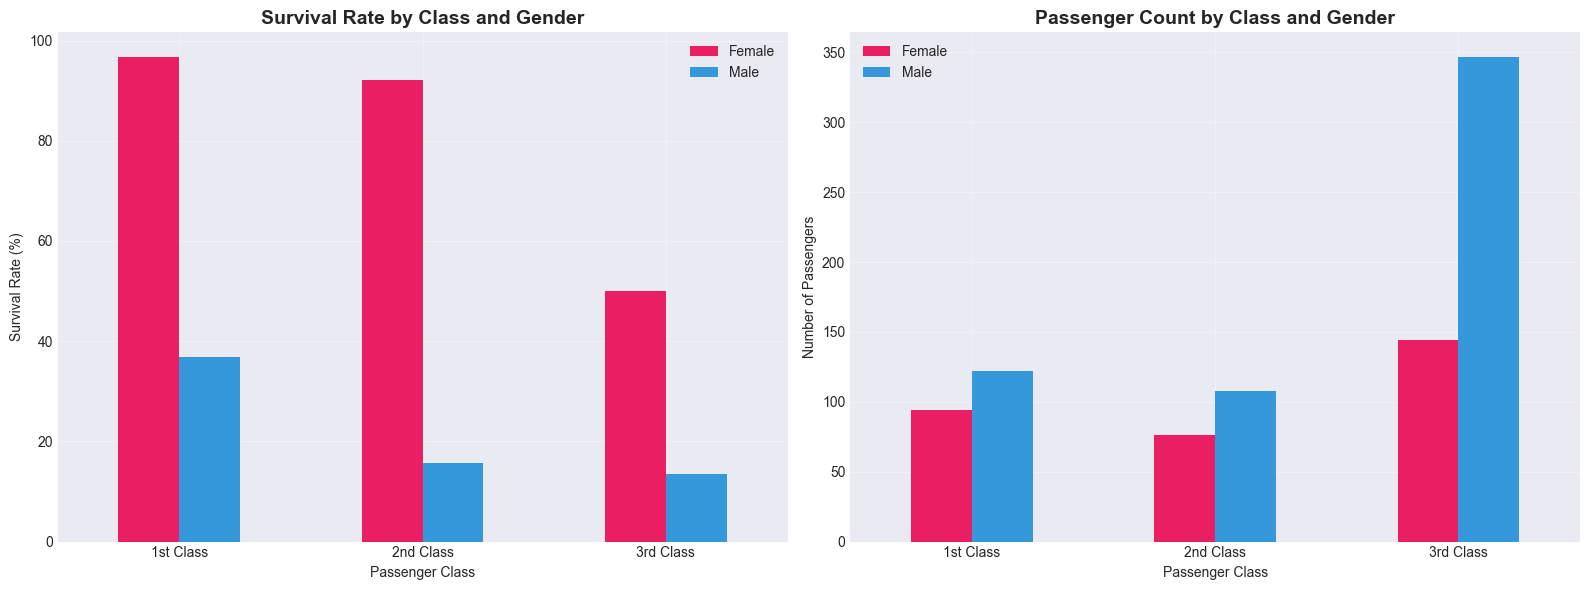

In [20]:
# Grouped bar chart: Survival Rate by Class and Gender
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Survival rate by class and gender
class_gender_survival = data.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100
class_gender_survival.plot(kind='bar', ax=axes[0], color=['#E91E63', '#3498DB'])
axes[0].set_title('Survival Rate by Class and Gender', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[0].legend(['Female', 'Male'])
axes[0].grid(alpha=0.3)

# Count by class and gender
class_gender_count = data.groupby(['Pclass', 'Sex']).size().unstack()
class_gender_count.plot(kind='bar', ax=axes[1], color=['#E91E63', '#3498DB'])
axes[1].set_title('Passenger Count by Class and Gender', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Number of Passengers')
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[1].legend(['Female', 'Male'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Age Groups Analysis

C:\Users\Shresth\AppData\Local\Temp\ipykernel_29536\1812458268.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age_group = data.groupby('AgeGroup')['Survived'].mean() * 100


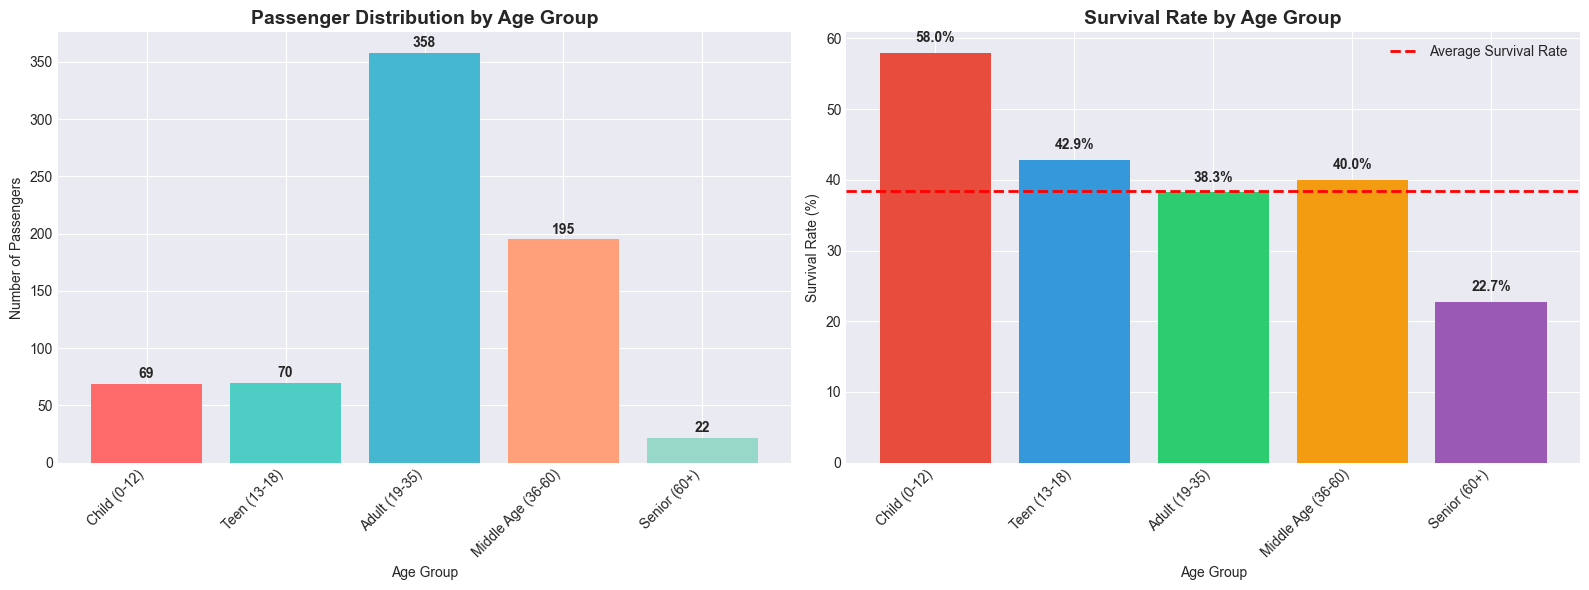

In [21]:
# Create Age Groups
data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100], 
                          labels=['Child (0-12)', 'Teen (13-18)', 'Adult (19-35)', 
                                  'Middle Age (36-60)', 'Senior (60+)'])

# Bar charts: Age Group Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age Group Distribution
age_group_counts = data['AgeGroup'].value_counts().sort_index()
axes[0].bar(range(len(age_group_counts)), age_group_counts.values, 
           color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'])
axes[0].set_title('Passenger Distribution by Age Group', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Passengers')
axes[0].set_xticks(range(len(age_group_counts)))
axes[0].set_xticklabels(age_group_counts.index, rotation=45, ha='right')
for i, v in enumerate(age_group_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Survival Rate by Age Group
survival_by_age_group = data.groupby('AgeGroup')['Survived'].mean() * 100
axes[1].bar(range(len(survival_by_age_group)), survival_by_age_group.values,
           color=['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6'])
axes[1].set_title('Survival Rate by Age Group', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xticks(range(len(survival_by_age_group)))
axes[1].set_xticklabels(survival_by_age_group.index, rotation=45, ha='right')
axes[1].axhline(y=data['Survived'].mean()*100, color='red', linestyle='--', 
                label='Average Survival Rate', linewidth=2)
for i, v in enumerate(survival_by_age_group.values):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Summary Statistics and Key Insights

KEY INSIGHTS FROM TITANIC DATASET

1. OVERALL SURVIVAL:
   - Total Passengers: 891
   - Survived: 342 (38.4%)
   - Died: 549 (61.6%)

2. GENDER IMPACT:
   - Female Survival Rate: 74.2%
   - Male Survival Rate: 18.9%
   - Females were 3.93x more likely to survive

3. CLASS IMPACT:
   - Class 1: 63.0% survival rate (216 passengers)
   - Class 2: 47.3% survival rate (184 passengers)
   - Class 3: 24.2% survival rate (491 passengers)

4. AGE STATISTICS:
   - Average Age: 29.7 years
   - Youngest: 0.4 years
   - Oldest: 80.0 years
   - Children (≤12) Survival Rate: 58.0%
   - Adults (>12) Survival Rate: 38.8%

5. FAMILY SIZE IMPACT:
   - Traveling Alone: 30.4% survival rate
   - Traveling with Family: 50.6% survival rate

6. FARE STATISTICS:
   - Average Fare: $32.20
   - Median Fare: $14.45
   - Highest Fare: $512.33

